# Taller: Abandono de producto financiero

## Regresión logística en Python · Clase 9

**Estudiantes:** Nicolás Montenegro Cedeño - Nicolás Barona
**Base:** `abandono_producto_financiero.csv` (10.000 clientes, corte transversal)

---

### El problema

Una entidad de banca de personas registró un aumento de clientes que cierran la relación. El
área de retención necesita pasar de la tasa agregada de la cartera a una probabilidad
individual:

$$
P(\text{abandono}=1 \mid x) = \Lambda(x\beta) = \frac{e^{x\beta}}{1 + e^{x\beta}} \in (0,1)
$$

El cálculo no sustituye la decisión comercial: ordena la cartera. Dice a quién contactar
primero, con qué umbral se declara a un cliente «en riesgo» y qué error se acepta, llamar a quien
se iba a quedar (falso positivo) frente a no ver a quien sí se va (falso negativo).

`abandono = 1` significa que el cliente cerró la relación; `abandono = 0`, que permanece. No es
mora ni *default*.

### Recorrido

| Sección | Qué se hace | Preguntas |
|---|---|---|
| 1 | Cargar, tipificar y contar variables | 1–4 |
| 2 | Univariado de $y$ y de las $x$ | 5 |
| 3 | Bivariado con `abandono` (boxplots, tablas, ji-cuadrado) | 6–10 |
| 4 | De la recta OLS al logit simple (edad) | 11–13 |
| 5 | Varios logits, AIC, odds ratios | 14–16 |
| 6 | Test, umbral, matriz de confusión e indicadores | 17–18 |
| 7 | Dos perfiles y lectura de riesgo | 19–21 |

Las respuestas están en celdas Markdown debajo de cada bloque de código, y todas las cifras
citadas provienen de esta corrida.

---

## 0. Configuración

Paquetes de clase: `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scipy`. No se usa `sklearn`,
porque el objetivo es inferencia (coeficientes, errores estándar, *odds ratios*) y no solo
predicción.

El CSV debe estar en la misma carpeta que este cuaderno, con el nombre
`abandono_producto_financiero.csv`.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import statsmodels
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Paleta fija para las dos clases de la respuesta
COL_PERM, COL_ABAN = "#2C5697", "#C0392B"

print("Versiones utilizadas")
print("-" * 32)
for nombre, mod in [("pandas", pd), ("numpy", np), ("statsmodels", statsmodels),
                    ("scipy", scipy)]:
    print(f"{nombre:12s} {mod.__version__}")

Versiones utilizadas
--------------------------------
pandas       3.0.3
numpy        2.5.0
statsmodels  0.14.6
scipy        1.18.0


In [2]:
# Localización del archivo (debe estar junto al cuaderno)
CANDIDATOS = [Path("abandono_producto_financiero.csv"),
              Path.home() / "Downloads" / "abandono_producto_financiero.csv",
              Path.home() / "Descargas" / "abandono_producto_financiero.csv"]
RUTA = next((p for p in CANDIDATOS if p.exists()), None)
if RUTA is None:
    raise FileNotFoundError(
        "No se encontró abandono_producto_financiero.csv. "
        "Colóquelo junto a este cuaderno.")
print(f"Archivo de datos: {RUTA.resolve()}")

Archivo de datos: C:\Users\nicom\Downloads\abandono_producto_financiero.csv


---

# 1. Estructura de los datos

Se carga la base, se inspecciona, se eliminan los identificadores que no entran a la fórmula
(`numero_fila`, `id_cliente`, `apellido`) y se fijan los tipos:

- `pais` → categórica con niveles Francia, Alemania, España (referencia: Francia)
- `sexo` → categórica con niveles Mujer, Hombre (referencia: Mujer)
- `abandono` → entero 0/1

El orden de los niveles importa: es lo que hace que `C(pais)` y `C(sexo)` usen las mismas
referencias que el enunciado.

In [3]:
df = pd.read_csv(RUTA)

print("PRIMERAS OBSERVACIONES")
display(df.head())
print(f"\nDimensión de la base cruda: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")

PRIMERAS OBSERVACIONES


,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0



Dimensión de la base cruda: 10000 filas x 14 columnas

Columnas: ['numero_fila', 'id_cliente', 'apellido', 'puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']


In [4]:
print("TIPOS DE DATO ASIGNADOS POR PANDAS")
print(df.dtypes.to_string())
print("\nINFORMACIÓN GENERAL")
df.info()

TIPOS DE DATO ASIGNADOS POR PANDAS
numero_fila             int64
id_cliente              int64
apellido                  str
puntaje_crediticio      int64
pais                      str
sexo                      str
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64

INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   numero_fila         10000 non-null  int64  
 1   id_cliente          10000 non-null  int64  
 2   apellido            10000 non-null  str    
 3   puntaje_crediticio  10000 non-null  int64  
 4   pais                10000 non-null  str    
 5   sexo                10000 non-null  str    
 6   edad                10000 non-

In [5]:
print("DESCRIPTIVO DE LA BASE CRUDA (variables numéricas)")
display(df.describe().T.round(2))

print("\nCONTROL DE CALIDAD")
print(f"  Valores faltantes      : {int(df.isna().sum().sum())}")
print(f"  Filas duplicadas       : {int(df.duplicated().sum())}")
print(f"  id_cliente únicos      : {df['id_cliente'].nunique()} de {len(df)}")
print(f"  ¿Una fila por cliente? : {df['id_cliente'].nunique() == len(df)}")

DESCRIPTIVO DE LA BASE CRUDA (variables numéricas)


,count,mean,std,min,25%,50%,75%,max
numero_fila,10000.0,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
id_cliente,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
puntaje_crediticio,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
edad,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
antiguedad,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
saldo,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
numero_productos,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
tiene_tarjeta,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
miembro_activo,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
salario_estimado,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48



CONTROL DE CALIDAD
  Valores faltantes      : 0
  Filas duplicadas       : 0
  id_cliente únicos      : 10000 de 10000
  ¿Una fila por cliente? : True


In [6]:
# Identificadores fuera + tipificación de factores
datos = df.drop(columns=["numero_fila", "id_cliente", "apellido"]).copy()

datos["pais"] = pd.Categorical(datos["pais"],
                               categories=["Francia", "Alemania", "España"])
datos["sexo"] = pd.Categorical(datos["sexo"],
                               categories=["Mujer", "Hombre"])
datos["abandono"] = datos["abandono"].astype(int)

print(f"Base de modelación: {datos.shape[0]} filas x {datos.shape[1]} columnas")
print(f"Variables eliminadas: numero_fila, id_cliente, apellido\n")
print(datos.dtypes.to_string())
print(f"\nNiveles de pais : {list(datos['pais'].cat.categories)}  "
      f"(referencia = {datos['pais'].cat.categories[0]})")
print(f"Niveles de sexo : {list(datos['sexo'].cat.categories)}  "
      f"(referencia = {datos['sexo'].cat.categories[0]})")

Base de modelación: 10000 filas x 11 columnas
Variables eliminadas: numero_fila, id_cliente, apellido

puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64

Niveles de pais : ['Francia', 'Alemania', 'España']  (referencia = Francia)
Niveles de sexo : ['Mujer', 'Hombre']  (referencia = Mujer)


In [7]:
# Clasificación explícita de las variables de modelación
CUANTITATIVAS = ["puntaje_crediticio", "edad", "antiguedad", "saldo",
                 "numero_productos", "salario_estimado"]
CATEGORICAS = ["pais", "sexo"]
BINARIAS = ["tiene_tarjeta", "miembro_activo"]
RESPUESTA = "abandono"

clasificacion = pd.DataFrame(
    [(v, "Cuantitativa", "Continua") for v in CUANTITATIVAS]
    + [(v, "Categórica", f"C({v}); ref. {datos[v].cat.categories[0]}") for v in CATEGORICAS]
    + [(v, "Binaria", "0 / 1") for v in BINARIAS]
    + [(RESPUESTA, "Binaria", "Respuesta y")],
    columns=["Variable", "Tipo", "Uso en el logit"])
display(clasificacion)

print(f"Cuantitativas                        : {len(CUANTITATIVAS)}")
print(f"Categóricas + binarias (con abandono): "
      f"{len(CATEGORICAS) + len(BINARIAS) + 1}")
print(f"Total de variables de modelación     : "
      f"{len(CUANTITATIVAS) + len(CATEGORICAS) + len(BINARIAS) + 1}")

,Variable,Tipo,Uso en el logit
0,puntaje_crediticio,Cuantitativa,Continua
1,edad,Cuantitativa,Continua
2,antiguedad,Cuantitativa,Continua
3,saldo,Cuantitativa,Continua
4,numero_productos,Cuantitativa,Continua
5,salario_estimado,Cuantitativa,Continua
6,pais,Categórica,C(pais); ref. Francia
7,sexo,Categórica,C(sexo); ref. Mujer
8,tiene_tarjeta,Binaria,0 / 1
9,miembro_activo,Binaria,0 / 1


Cuantitativas                        : 6
Categóricas + binarias (con abandono): 5
Total de variables de modelación     : 11


### Respuestas (sección 1)

**1. ¿Cuántas variables tiene la base cruda? ¿Cuántas quedan para el modelo?**

La base cruda tiene 14 variables. Se eliminan tres identificadores: `numero_fila`
(número de fila), `id_cliente` (llave administrativa) y `apellido` (texto libre), porque no son
atributos del cliente que puedan explicar su decisión: son etiquetas. Quedan 11 variables:
10 explicativas más la respuesta `abandono`.

**2. ¿Cuántas son cuantitativas?**

Seis: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` y
`salario_estimado`. `numero_productos` es un conteo entero (1 a 4), pero el diccionario indica
tratarlo como continua dentro del logit.

**3. ¿Cuántas son categóricas o binarias (incluyendo `abandono`)?**

Cinco: `pais` (3 niveles), `sexo` (2 niveles), `tiene_tarjeta` (0/1), `miembro_activo` (0/1) y
la respuesta `abandono` (0/1). Seis cuantitativas más cinco categóricas suman las 11 variables de
modelación.

**4. ¿Qué implica esta mezcla para el logit en Python (`C(pais)`, `C(sexo)` frente a dummies hechas a mano)?**

Implica que hay que decidir cómo entran los factores, y `C()` lo resuelve de forma más segura
que construir dummies manualmente, por cuatro razones:

1. **Fija la referencia de manera explícita y estable.** Al declarar `pais` como `Categorical` con
   el orden *Francia, Alemania, España*, `C(pais)` toma Francia como base. Sin ese paso, pandas
   ordenaría alfabéticamente (*Alemania, España, Francia*) y los coeficientes se leerían contra
   Alemania, cambiando la interpretación de todos los *odds ratios* del país.
2. **Evita la trampa de la variable ficticia.** `C()` genera $k-1$ columnas automáticamente. Crear
   las $k$ dummies a mano produce colinealidad perfecta con el intercepto.
3. **Garantiza consistencia entre conjuntos de datos.** La misma fórmula se aplica a `Train_Data`,
   a `Test_Data` y al DataFrame de perfiles de la sección 7. Con dummies manuales habría que
   replicar exactamente la misma codificación en cada objeto nuevo, y ahí es donde se cuelan los
   errores silenciosos.
4. **`statsmodels` reconoce el bloque.** Sabe que las dummies de un mismo factor pertenecen a una
   sola variable, lo que permite contrastes conjuntos sobre todo el factor.

Las variables ya binarias (`tiene_tarjeta`, `miembro_activo`) no necesitan `C()`: al estar
codificadas 0/1, su coeficiente ya se lee como el efecto de pasar de 0 a 1.

---
> 📌 Cierre de sección: `git commit -m "Punto 1: estructura de los datos"` y `git push`.

---

# 2. Descriptivo univariado

Primero la respuesta (cuántos abandonan y en qué proporción) y después la forma de las
explicativas.

In [8]:
conteo = datos["abandono"].value_counts().sort_index()
propor = datos["abandono"].value_counts(normalize=True).sort_index()

tabla_y = pd.DataFrame({
    "Etiqueta": ["Permanece (0)", "Abandonó (1)"],
    "Frecuencia": conteo.values,
    "Proporción": propor.values,
    "Porcentaje": (propor.values * 100).round(2)})
display(tabla_y)

TASA = datos["abandono"].mean()
print(f"Tasa de abandono de la cartera : {TASA:.4f}  ({TASA*100:.2f} %)")
print(f"Tasa de permanencia            : {1-TASA:.4f}  ({(1-TASA)*100:.2f} %)")
print(f"Razón de desbalance            : {conteo[0]/conteo[1]:.2f} a 1")

,Etiqueta,Frecuencia,Proporción,Porcentaje
0,Permanece (0),7963,0.7963,79.63
1,Abandonó (1),2037,0.2037,20.37


Tasa de abandono de la cartera : 0.2037  (20.37 %)
Tasa de permanencia            : 0.7963  (79.63 %)
Razón de desbalance            : 3.91 a 1


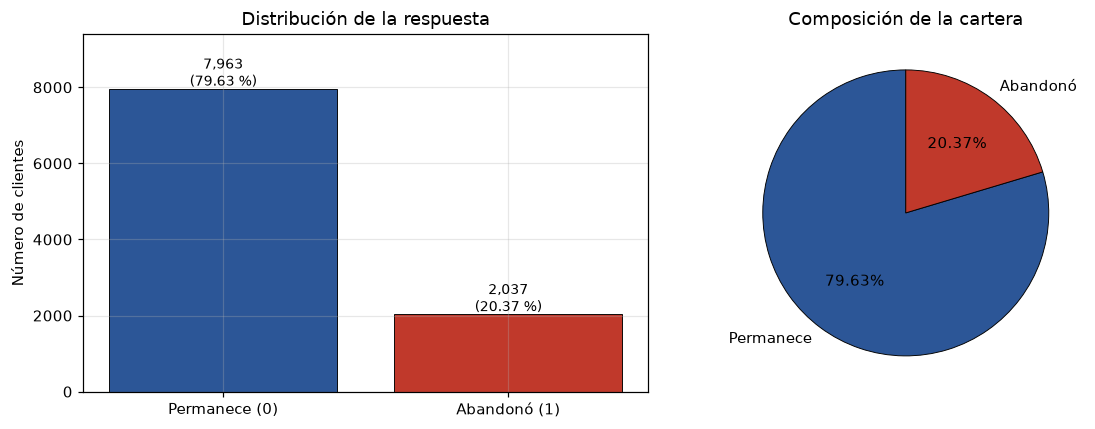

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(["Permanece (0)", "Abandonó (1)"], conteo.values,
            color=[COL_PERM, COL_ABAN], edgecolor="black", linewidth=0.6)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 80, f"{v:,}\n({v/len(datos)*100:.2f} %)",
                 ha="center", fontsize=9)
axes[0].set_ylabel("Número de clientes")
axes[0].set_title("Distribución de la respuesta")
axes[0].set_ylim(0, conteo.max() * 1.18)

axes[1].pie(conteo.values, labels=["Permanece", "Abandonó"],
            colors=[COL_PERM, COL_ABAN], autopct="%1.2f%%",
            startangle=90, wedgeprops={"edgecolor": "black", "linewidth": 0.6})
axes[1].set_title("Composición de la cartera")

plt.tight_layout()
plt.show()

In [10]:
print("DESCRIPTIVO DE LAS VARIABLES CUANTITATIVAS")
desc = datos[CUANTITATIVAS].describe().T
desc["asimetría"] = datos[CUANTITATIVAS].skew()
display(desc.round(2))

print(f"\nClientes con saldo exactamente 0: {int((datos['saldo']==0).sum())} "
      f"({(datos['saldo']==0).mean()*100:.2f} % de la base)")

DESCRIPTIVO DE LAS VARIABLES CUANTITATIVAS


,count,mean,std,min,25%,50%,75%,max,asimetría
puntaje_crediticio,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00,-0.07
edad,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00,1.01
antiguedad,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00,0.01
saldo,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09,-0.14
numero_productos,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00,0.75
salario_estimado,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48,0.00



Clientes con saldo exactamente 0: 3617 (36.17 % de la base)


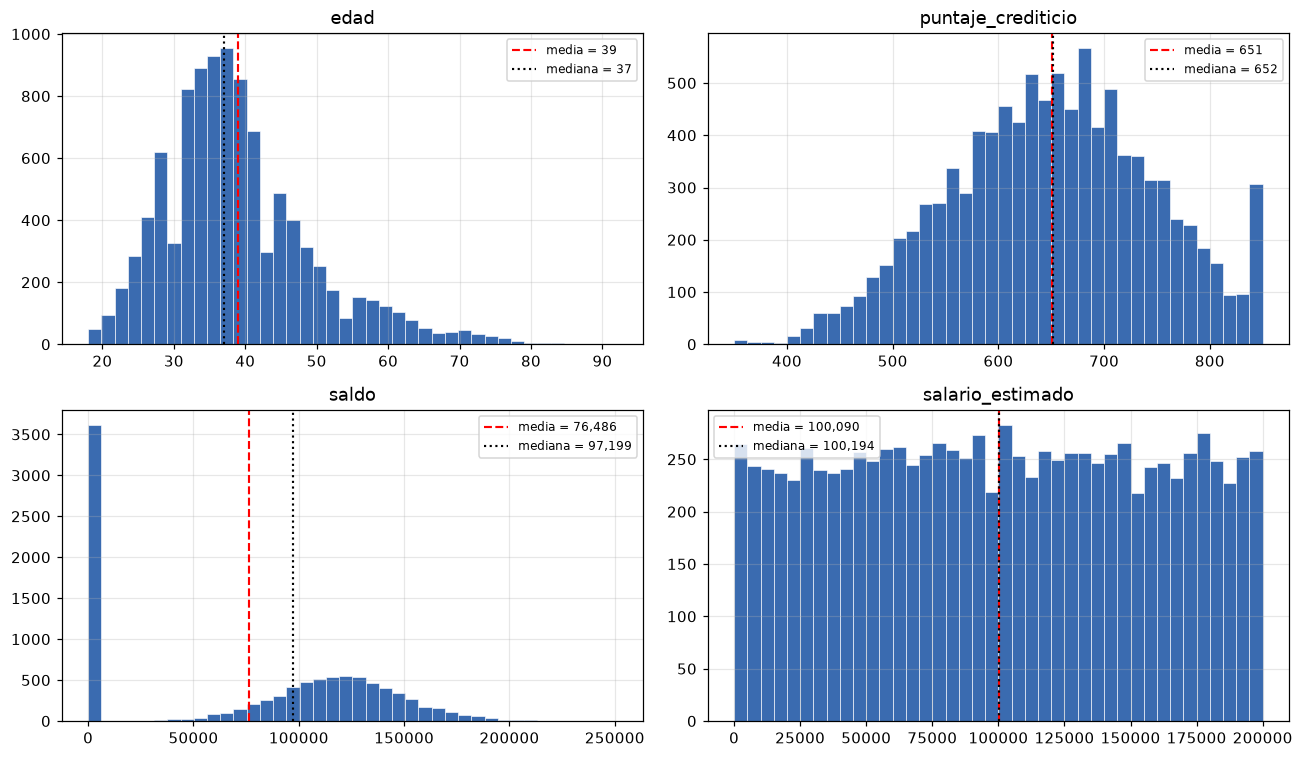

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, var in zip(axes.flat, ["edad", "puntaje_crediticio", "saldo",
                               "salario_estimado"]):
    ax.hist(datos[var], bins=40, color="#3A6BB0", edgecolor="white", linewidth=0.4)
    ax.axvline(datos[var].mean(), color="red", ls="--", lw=1.4,
               label=f"media = {datos[var].mean():,.0f}")
    ax.axvline(datos[var].median(), color="black", ls=":", lw=1.4,
               label=f"mediana = {datos[var].median():,.0f}")
    ax.set_title(var)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
print("TABLAS DE FRECUENCIA DE LAS CATEGÓRICAS Y BINARIAS\n")
for var in ["pais", "sexo", "numero_productos", "miembro_activo", "tiene_tarjeta"]:
    t = pd.DataFrame({
        "Frecuencia": datos[var].value_counts(sort=False),
        "Porcentaje": (datos[var].value_counts(normalize=True, sort=False) * 100).round(2)})
    t.index.name = var
    display(t)

TABLAS DE FRECUENCIA DE LAS CATEGÓRICAS Y BINARIAS



,Frecuencia,Porcentaje
pais,,
Francia,5014,50.14
Alemania,2509,25.09
España,2477,24.77


,Frecuencia,Porcentaje
sexo,,
Mujer,4543,45.43
Hombre,5457,54.57


,Frecuencia,Porcentaje
numero_productos,,
1,5084,50.84
3,266,2.66
2,4590,45.90
4,60,0.60


,Frecuencia,Porcentaje
miembro_activo,,
1,5151,51.51
0,4849,48.49


,Frecuencia,Porcentaje
tiene_tarjeta,,
1,7055,70.55
0,2945,29.45


### Respuestas (sección 2)

**5. ¿Qué porcentaje de la base abandonó? ¿Por qué un clasificador que siempre diga «permanece» ya
parece bueno si uno solo mira la *accuracy*?**

Abandonó el 20,37 % de la cartera: 2.037 clientes de 10.000. Permanece el 79,63 %, es decir
7.963. El desbalance es de casi 4 a 1 a favor de la clase 0.

Ese desbalance fija un piso engañoso para la exactitud. Un clasificador que ignore por completo
las variables y responda siempre «permanece» acierta en los 7.963 casos de la clase mayoritaria y
falla en los 2.037 restantes:

$$
\text{Exactitud del clasificador trivial} = \frac{7.963}{10.000} = 0{,}7963 \approx 79{,}6\,\%
$$

Casi un 80 % de aciertos sin haber aprendido nada. El problema es que su sensibilidad es
exactamente 0: no detecta a ni un solo cliente que se va, que es justamente lo único que le
interesa al área de retención.

De aquí se siguen dos consecuencias prácticas para el resto del taller:

- La exactitud solo es informativa comparada contra el 79,63 %. Un modelo con 82 % de acierto
  no es «bueno»: aporta apenas 2 puntos sobre no hacer nada.
- Hay que mirar sensibilidad y especificidad por separado (sección 6). Son los indicadores que
  distinguen un modelo útil de uno que simplemente se apoya en la clase mayoritaria.

**Lo que muestran las demás tablas.** `edad` está sesgada a la derecha (media 38,9; mediana 37;
máximo 92). `saldo` tiene una particularidad importante: 3.617 clientes (36,17 %) registran saldo exactamente cero, lo que produce una distribución bimodal (una masa en 0 y una campana alrededor
de 120.000) y no un simple sesgo. `salario_estimado` es prácticamente uniforme entre 11 y 200.000,
lo que hace sospechar que es una variable simulada y anticipa que aportará poco. En cuanto a los
factores, Francia concentra la mitad de la cartera (5.014) y Alemania y España se reparten el resto
por partes casi iguales; el 70,6 % tiene tarjeta y la base está casi partida en dos por
`miembro_activo` (51,5 % activos).

---
> 📌 Cierre de sección: `git commit -m "Punto 2: descriptivo univariado"` y `git push`.

---

# 3. Bivariado con la respuesta

Se compara cada variable entre quien abandona y quien permanece: boxplots y medianas para las
continuas, tablas cruzadas y ji-cuadrado para las categóricas.

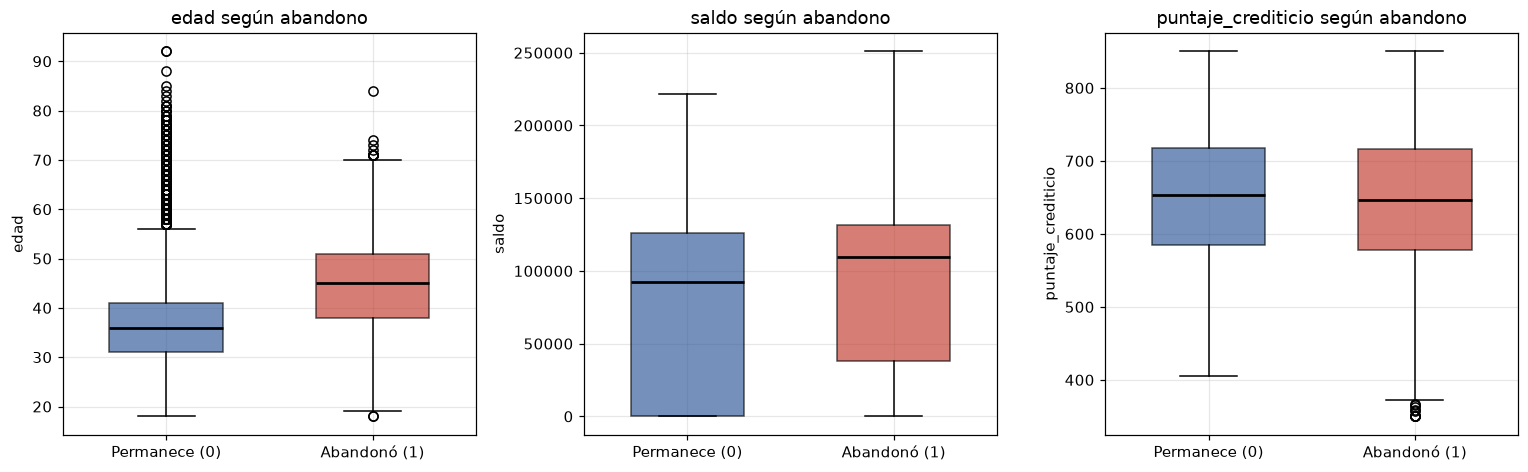

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, var in zip(axes, ["edad", "saldo", "puntaje_crediticio"]):
    grupos = [datos.loc[datos["abandono"] == k, var] for k in (0, 1)]
    bp = ax.boxplot(grupos, patch_artist=True, widths=0.55,
                    medianprops={"color": "black", "linewidth": 1.8})
    for caja, color in zip(bp["boxes"], [COL_PERM, COL_ABAN]):
        caja.set_facecolor(color)
        caja.set_alpha(0.65)
    # set_xticklabels en lugar del argumento labels=, que cambió de nombre
    # en matplotlib 3.9+ (labels -> tick_labels)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Permanece (0)", "Abandonó (1)"])
    ax.set_title(f"{var} según abandono")
    ax.set_ylabel(var)
plt.tight_layout()
plt.show()

In [14]:
print("MEDIANAS POR GRUPO")
medianas = datos.groupby("abandono")[CUANTITATIVAS].median().T
medianas.columns = ["Permanece (0)", "Abandonó (1)"]
medianas["Diferencia"] = medianas["Abandonó (1)"] - medianas["Permanece (0)"]
display(medianas.round(2))

print("MEDIAS POR GRUPO")
medias = datos.groupby("abandono")[CUANTITATIVAS].mean().T
medias.columns = ["Permanece (0)", "Abandonó (1)"]
medias["Diferencia"] = medias["Abandonó (1)"] - medias["Permanece (0)"]
display(medias.round(2))

MEDIANAS POR GRUPO


,Permanece (0),Abandonó (1),Diferencia
puntaje_crediticio,653.00,646.00,-7.00
edad,36.00,45.00,9.00
antiguedad,5.00,5.00,0.00
saldo,92072.68,109349.29,17276.61
numero_productos,2.00,1.00,-1.00
salario_estimado,99645.04,102460.84,2815.80


MEDIAS POR GRUPO


,Permanece (0),Abandonó (1),Diferencia
puntaje_crediticio,651.85,645.35,-6.50
edad,37.41,44.84,7.43
antiguedad,5.03,4.93,-0.10
saldo,72745.30,91108.54,18363.24
numero_productos,1.54,1.48,-0.07
salario_estimado,99738.39,101465.68,1727.29


In [15]:
# Contraste no paramétrico de la diferencia entre grupos (complementa el boxplot)
print("PRUEBA DE MANN-WHITNEY (H0: misma distribución en ambos grupos)\n")
filas = []
for var in CUANTITATIVAS:
    a = datos.loc[datos["abandono"] == 1, var]
    b = datos.loc[datos["abandono"] == 0, var]
    u, p = scipy.stats.mannwhitneyu(a, b, alternative="two-sided")
    filas.append({"Variable": var, "Mediana abandonó": a.median(),
                  "Mediana permanece": b.median(), "U": u, "p-value": p,
                  "Decisión (5%)": "Difieren" if p < 0.05 else "No difieren"})
display(pd.DataFrame(filas).round(4))

PRUEBA DE MANN-WHITNEY (H0: misma distribución en ambos grupos)



,Variable,Mediana abandonó,Mediana permanece,U,p-value,Decisión (5%)
0,puntaje_crediticio,646.00,653.00,7839548.0,0.0199,Difieren
1,edad,45.00,36.00,11874649.5,0.0000,Difieren
2,antiguedad,5.00,5.00,7948575.5,0.1622,No difieren
3,saldo,109349.29,92072.68,9371186.5,0.0000,Difieren
4,numero_productos,1.00,2.00,6830625.5,0.0000,Difieren
5,salario_estimado,102460.84,99645.04,8250768.0,0.2271,No difieren


In [16]:
def tabla_chi2(var, objetivo="abandono", datos=datos):
    '''Tabla cruzada, tasa de abandono por nivel y prueba ji-cuadrado.'''
    obs = pd.crosstab(datos[var], datos[objetivo])
    chi2, p, gl, esp = chi2_contingency(obs)
    n = obs.values.sum()
    v_cramer = np.sqrt(chi2 / (n * (min(obs.shape) - 1)))

    resumen = obs.copy()
    resumen.columns = ["Permanece (0)", "Abandonó (1)"]
    resumen["Total"] = resumen.sum(axis=1)
    resumen["Tasa de abandono (%)"] = (resumen["Abandonó (1)"] /
                                       resumen["Total"] * 100).round(2)
    print(f"--- {var} vs {objetivo} ---")
    display(resumen)
    print(f"    Ji-cuadrado = {chi2:,.2f}   gl = {gl}   p-value = {p:.3e}")
    print(f"    V de Cramér = {v_cramer:.4f}   "
          f"(0 = sin asociación; 1 = asociación perfecta)\n")
    return {"Variable": var, "Chi2": chi2, "gl": gl, "p-value": p,
            "V de Cramér": v_cramer}


resultados_chi2 = [tabla_chi2(v) for v in
                   ["miembro_activo", "numero_productos", "pais", "sexo", "tiene_tarjeta"]]

--- miembro_activo vs abandono ---


,Permanece (0),Abandonó (1),Total,Tasa de abandono (%)
miembro_activo,,,,
0,3547,1302,4849,26.85
1,4416,735,5151,14.27


    Ji-cuadrado = 242.99   gl = 1   p-value = 8.786e-55
    V de Cramér = 0.1559   (0 = sin asociación; 1 = asociación perfecta)

--- numero_productos vs abandono ---


,Permanece (0),Abandonó (1),Total,Tasa de abandono (%)
numero_productos,,,,
1,3675,1409,5084,27.71
2,4242,348,4590,7.58
3,46,220,266,82.71
4,0,60,60,100.00


    Ji-cuadrado = 1,503.63   gl = 3   p-value = 0.000e+00
    V de Cramér = 0.3878   (0 = sin asociación; 1 = asociación perfecta)

--- pais vs abandono ---


...

    Ji-cuadrado = 301.26   gl = 2   p-value = 3.830e-66
    V de Cramér = 0.1736   (0 = sin asociación; 1 = asociación perfecta)

--- sexo vs abandono ---


,Permanece (0),Abandonó (1),Total,Tasa de abandono (%)
sexo,,,,
Mujer,3404,1139,4543,25.07
Hombre,4559,898,5457,16.46


    Ji-cuadrado = 112.92   gl = 1   p-value = 2.248e-26
    V de Cramér = 0.1063   (0 = sin asociación; 1 = asociación perfecta)

--- tiene_tarjeta vs abandono ---


,Permanece (0),Abandonó (1),Total,Tasa de abandono (%)
tiene_tarjeta,,,,
0,2332,613,2945,20.81
1,5631,1424,7055,20.18


    Ji-cuadrado = 0.47   gl = 1   p-value = 4.924e-01
    V de Cramér = 0.0069   (0 = sin asociación; 1 = asociación perfecta)



In [17]:
print("RANKING DE ASOCIACIÓN CON EL ABANDONO (variables categóricas)")
rank = (pd.DataFrame(resultados_chi2)
        .sort_values("V de Cramér", ascending=False)
        .reset_index(drop=True))
rank["Significativa (5%)"] = np.where(rank["p-value"] < 0.05, "Sí", "No")
display(rank.round(4))

RANKING DE ASOCIACIÓN CON EL ABANDONO (variables categóricas)


,Variable,Chi2,gl,p-value,V de Cramér,Significativa (5%)
0,numero_productos,1503.6294,3,0.0000,0.3878,Sí
1,pais,301.2553,2,0.0000,0.1736,Sí
2,miembro_activo,242.9853,1,0.0000,0.1559,Sí
3,sexo,112.9186,1,0.0000,0.1063,Sí
4,tiene_tarjeta,0.4713,1,0.4924,0.0069,No


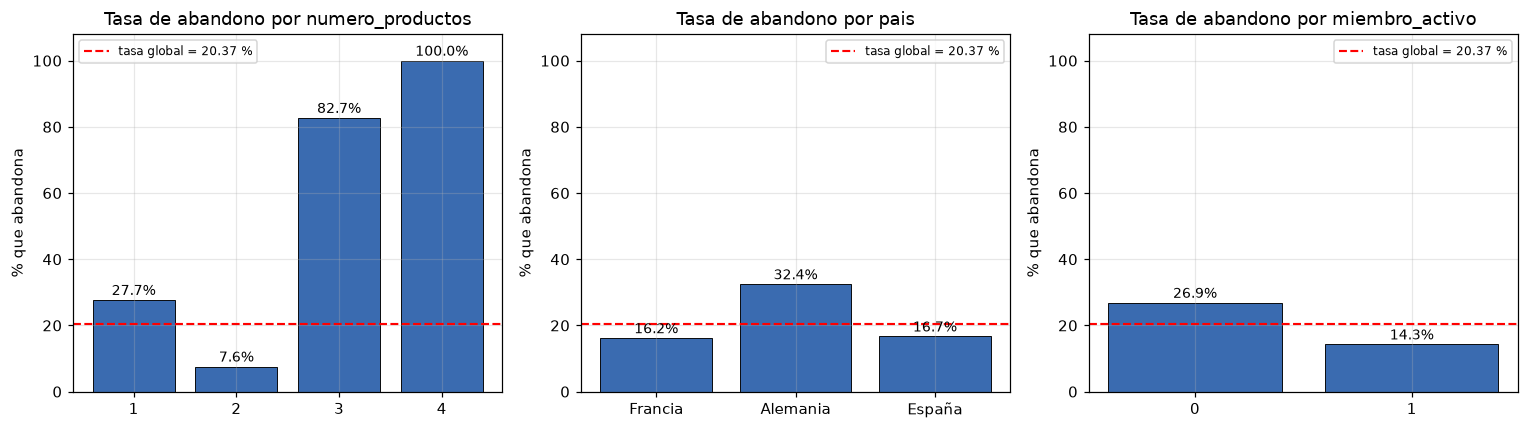

In [18]:
# Tasa de abandono por nivel: la lectura visual del ranking
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, ["numero_productos", "pais", "miembro_activo"]):
    tasa = datos.groupby(var, observed=True)["abandono"].mean() * 100
    barras = ax.bar([str(i) for i in tasa.index], tasa.values,
                    color="#3A6BB0", edgecolor="black", linewidth=0.6)
    ax.axhline(TASA * 100, color="red", ls="--", lw=1.4,
               label=f"tasa global = {TASA*100:.2f} %")
    for b, v in zip(barras, tasa.values):
        ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%",
                ha="center", fontsize=9)
    ax.set_title(f"Tasa de abandono por {var}")
    ax.set_ylabel("% que abandona")
    ax.set_ylim(0, 108)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Respuestas (sección 3)

**6. Distribución de `edad` entre quien abandona y quien permanece.**

Es la diferencia más nítida entre las continuas. La mediana de quien abandona es 45 años frente
a 36 de quien permanece: nueve años de diferencia. El boxplot muestra la caja completa de
los que abandonan desplazada hacia arriba, con un recorrido intercuartílico que apenas se solapa
con el de quienes permanecen. La prueba de Mann-Whitney confirma que la diferencia no es
atribuible al azar ($p \approx 3{,}2\times10^{-230}$).

La lectura de negocio es que el riesgo de abandono se concentra en la franja madura de la
cartera, no en los clientes jóvenes.

**7. `saldo` y `puntaje_crediticio` entre los dos grupos.**

`saldo` se comporta de forma contraintuitiva: quien abandona tiene más saldo
(mediana 109.349 frente a 92.073). La diferencia es significativa ($p \approx 1{,}1\times10^{-28}$),
pero conviene no leerla de forma directa, y por dos motivos:

- El 36,17 % de la base tiene saldo exactamente cero, y ese cero se reparte de manera muy
  desigual: es el 39,14 % de quienes permanecen y solo el 24,55 % de quienes abandonan. La mediana
  del grupo que permanece está arrastrada hacia abajo por esa masa en cero.
- Ese cero está además confundido con el país (se verifica en la celda siguiente): en Alemania
  ningún cliente tiene saldo cero, mientras que en Francia y España cerca de la mitad lo tiene. Y
  Alemania es justamente el país con más abandono. Buena parte del «efecto saldo» es en realidad
  un efecto país.

`puntaje_crediticio` prácticamente no discrimina: mediana 646 frente a 653, siete puntos en
una escala de 350 a 850. El $p$-value es 0,0199 (formalmente significativo al 5 %), pero eso es un
artefacto del tamaño muestral: con $n = 10.000$ casi cualquier diferencia mínima resulta
significativa. Las cajas de los dos grupos se solapan casi por completo, y este resultado anticipa
que la variable no será significativa en el logit multivariado.

**8. `miembro_activo` y abandono. ¿Los clientes activos presentan menor abandono?**

**Sí, y la diferencia es grande.** Entre los inactivos abandona el 26,85 %; entre los activos,
el 14,27 %. La tasa de los inactivos casi duplica la de los activos.
$\chi^2 = 242{,}99$ con 1 grado de libertad y $p \approx 8{,}8\times10^{-55}$: se rechaza la
independencia de forma contundente.

Es además la variable más accionable del conjunto: a diferencia de la edad o del país, la
actividad del cliente sí puede intervenirse con campañas de reactivación.

**9. `numero_productos` y abandono. ¿Más productos se asocia siempre con menos abandono?**

**No. La relación no es monótona: tiene forma de U.**

| Productos | Clientes | Tasa de abandono |
|---:|---:|---:|
| 1 | 5.084 | 27,71 % |
| 2 | 4.590 | 7,58 % |
| 3 | 266 | 82,71 % |
| 4 | 60 | 100,00 % |

Pasar de uno a dos productos reduce el abandono en 20 puntos porcentuales, pero de dos en
adelante se dispara: con tres productos abandonan cuatro de cada cinco clientes, y los
sesenta clientes con cuatro productos abandonaron sin excepción.

La lectura natural es que dos productos describe al cliente vinculado y estable, mientras que tres
o cuatro no señalan mayor fidelidad sino probablemente una situación anómala: ventas cruzadas mal
dirigidas, o clientes en proceso de reestructurar su relación antes de cerrarla.

Este resultado tiene una consecuencia técnica que se verá en la sección 5: al entrar la variable
como continua, el logit le ajusta una sola pendiente y la U se promedia hasta casi
desaparecer.

**10. ¿Qué variable parece tener mayor relación con el abandono?**

Entre las categóricas, `numero_productos` por un margen amplio, y la justificación es la
V de Cramér, que normaliza el ji-cuadrado por el tamaño muestral y las dimensiones de la tabla
(el $\chi^2$ crudo no es comparable entre variables con distinto número de niveles):

| Variable | $\chi^2$ | gl | V de Cramér |
|---|---:|---:|---:|
| `numero_productos` | 1.503,63 | 3 | 0,3878 |
| `pais` | 301,26 | 2 | 0,1736 |
| `miembro_activo` | 242,99 | 1 | 0,1559 |
| `sexo` | 112,92 | 1 | 0,1063 |
| `tiene_tarjeta` | 0,47 | 1 | 0,0069 |

`numero_productos` más que duplica a la siguiente. Entre las continuas, la más asociada es
`edad`, con el $p$-value más extremo de todas las pruebas realizadas.

Conviene señalar el otro extremo: `tiene_tarjeta` no tiene ninguna relación con el abandono
($\chi^2 = 0{,}47$; $p = 0{,}492$; tasas de 20,81 % frente a 20,18 %). Es el primer candidato a
quedar fuera del modelo, y en la sección 5 se confirma.

In [19]:
# Verificación de la confusión entre saldo y país señalada en la respuesta 7
print("EL CERO DE saldo NO SE REPARTE AL AZAR ENTRE PAÍSES\n")
ceros = pd.DataFrame({
    "Clientes": datos.groupby("pais", observed=True).size(),
    "Con saldo = 0 (%)": (datos.groupby("pais", observed=True)["saldo"]
                          .apply(lambda s: (s == 0).mean() * 100)).round(2),
    "Tasa de abandono (%)": (datos.groupby("pais", observed=True)["abandono"]
                             .mean() * 100).round(2)})
display(ceros)

print("Tasa de abandono según el saldo sea cero o positivo:")
print(f"  saldo = 0 : {datos.loc[datos['saldo']==0, 'abandono'].mean()*100:.2f} %")
print(f"  saldo > 0 : {datos.loc[datos['saldo']>0, 'abandono'].mean()*100:.2f} %")

EL CERO DE saldo NO SE REPARTE AL AZAR ENTRE PAÍSES



,Clientes,Con saldo = 0 (%),Tasa de abandono (%)
pais,,,
Francia,5014,48.22,16.15
Alemania,2509,0.00,32.44
España,2477,48.41,16.67


Tasa de abandono según el saldo sea cero o positivo:
  saldo = 0 : 13.82 %
  saldo > 0 : 24.08 %


**Confirmación de la advertencia sobre `saldo`.** En Alemania ningún cliente registra saldo
cero, mientras que en Francia y España lo hace cerca de la mitad (48,22 % y 48,41 %). Como
Alemania duplica la tasa de abandono de los otros dos países (32,44 % frente a 16,15 % y 16,67 %),
tener saldo positivo y abandonar aparecen asociados a través del país, no necesariamente por
una relación propia.

Por eso la tasa de abandono de quienes tienen saldo cero (13,82 %) es menor que la de quienes
tienen saldo positivo (24,08 %): el grupo de saldo cero es casi enteramente francés y español. Es
un recordatorio de por qué el análisis bivariado no basta y hace falta el modelo multivariado, que
estima el efecto de cada variable manteniendo las demás constantes.

---
> 📌 Cierre de sección: `git commit -m "Punto 3: analisis bivariado"` y `git push`.

---

# 4. De la recta al logit

Hay una $x$ continua (`edad`) y una respuesta 0/1. Se estima primero el modelo lineal de
probabilidad con `smf.ols` y después el logit con `smf.logit`, como en la Clase 8. El OLS se
usa solo como contraste: sirve para ver por qué no puede leerse como probabilidad.

In [20]:
# Modelo lineal de probabilidad (solo como contraste)
ols_simple = smf.ols("abandono ~ edad", data=datos).fit()
print(ols_simple.summary().tables[0])
print(ols_simple.summary().tables[1])

                            OLS Regression Results                            
Dep. Variable:               abandono   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     886.1
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          1.24e-186
Time:                        15:08:52   Log-Likelihood:                -4670.4
No. Observations:               10000   AIC:                             9345.
Df Residuals:                    9998   BIC:                             9359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2228      0.015    -15.014      0.0

In [21]:
ajustados_ols = ols_simple.predict(datos)
fuera = ((ajustados_ols < 0) | (ajustados_ols > 1)).sum()

print("EL PROBLEMA DE LA RECTA")
print("=" * 56)
print(f"Valor ajustado mínimo : {ajustados_ols.min():.4f}")
print(f"Valor ajustado máximo : {ajustados_ols.max():.4f}")
print(f"Observaciones con probabilidad fuera de [0, 1]: {int(fuera)}")
print()
print("Probabilidad que predice la recta a distintas edades:")
for e in [18, 20, 30, 40, 60, 80, 92]:
    v = ols_simple.params["Intercept"] + ols_simple.params["edad"] * e
    marca = "  <-- imposible" if (v < 0 or v > 1) else ""
    print(f"   edad = {e:3d}  ->  P = {v:7.4f}{marca}")

EL PROBLEMA DE LA RECTA
Valor ajustado mínimo : -0.0255
Valor ajustado máximo : 0.7853
Observaciones con probabilidad fuera de [0, 1]: 89

Probabilidad que predice la recta a distintas edades:
   edad =  18  ->  P = -0.0255  <-- imposible
   edad =  20  ->  P = -0.0036  <-- imposible
   edad =  30  ->  P =  0.1059
   edad =  40  ->  P =  0.2155
   edad =  60  ->  P =  0.4347
   edad =  80  ->  P =  0.6538
   edad =  92  ->  P =  0.7853


In [22]:
# Logit simple sobre la misma x
logit_simple = smf.logit("abandono ~ edad", data=datos).fit(disp=0)
print(logit_simple.summary())

                           Logit Regression Results                           
Dep. Variable:               abandono   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.07505
Time:                        15:08:52   Log-Likelihood:                -4675.5
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                5.077e-167
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.9286      0.103    -38.096      0.000      -4.131      -3.726
edad           0.0629      0.002     26.614      0.000       0.058       0.068


In [23]:
b0 = logit_simple.params["Intercept"]
b1 = logit_simple.params["edad"]

print("LOGIT SIMPLE (LECTURA DE LOS COEFICIENTES)")
print("=" * 56)
print(f"Intercepto (beta_0)      : {b0:.6f}")
print(f"Coeficiente de edad      : {b1:.6f}")
print(f"Odds ratio de edad       : {np.exp(b1):.6f}   (por cada año)")
print(f"Odds ratio por década    : {np.exp(10*b1):.4f}   (por cada 10 años)")
print(f"AIC                      : {logit_simple.aic:.2f}")
print(f"Pseudo R2 (McFadden)     : {logit_simple.prsquared:.4f}")
print()
print("Probabilidad estimada por el logit:")
for e in [18, 30, 40, 50, 60, 80, 92]:
    p = logit_simple.predict(pd.DataFrame({"edad": [e]})).iloc[0]
    print(f"   edad = {e:3d}  ->  P = {p:.4f}")

LOGIT SIMPLE (LECTURA DE LOS COEFICIENTES)
Intercepto (beta_0)      : -3.928603
Coeficiente de edad      : 0.062945
Odds ratio de edad       : 1.064968   (por cada año)
Odds ratio por década    : 1.8766   (por cada 10 años)
AIC                      : 9355.05
Pseudo R2 (McFadden)     : 0.0750

Probabilidad estimada por el logit:
   edad =  18  ->  P = 0.0576
   edad =  30  ->  P = 0.1150
   edad =  40  ->  P = 0.1961
   edad =  50  ->  P = 0.3140
   edad =  60  ->  P = 0.4621
   edad =  80  ->  P = 0.7516
   edad =  92  ->  P = 0.8656


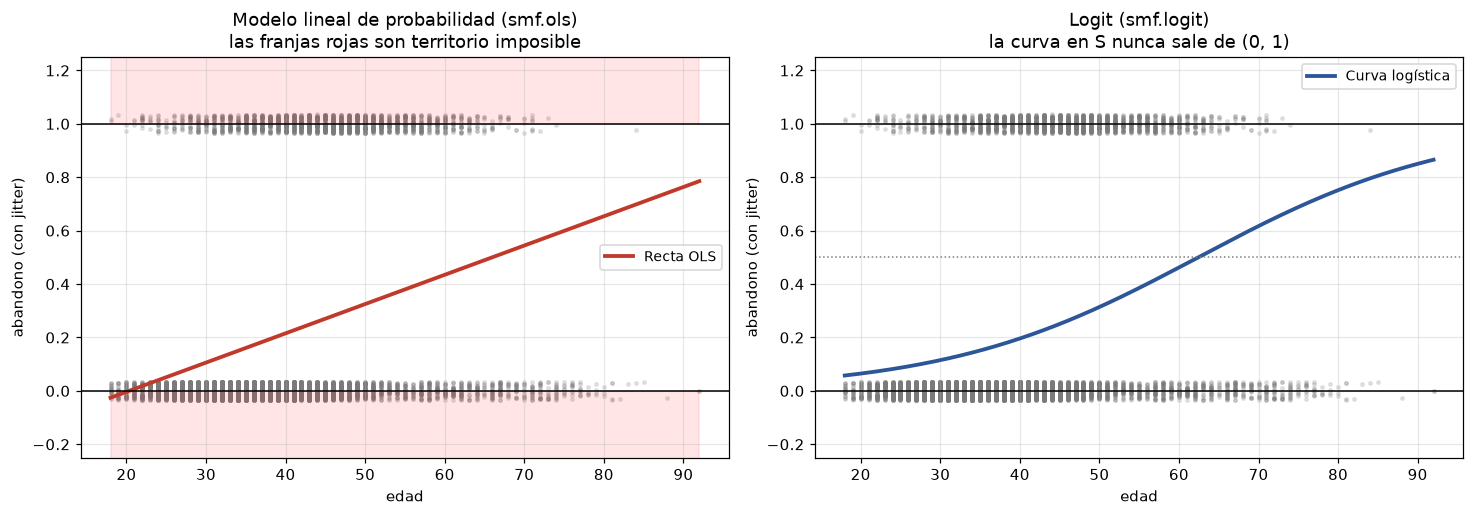

In [24]:
# La recta frente a la curva en S
rng_jitter = np.random.default_rng(8)
jitter = rng_jitter.uniform(-0.035, 0.035, len(datos))
rejilla = pd.DataFrame({"edad": np.linspace(datos["edad"].min(),
                                            datos["edad"].max(), 300)})

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

# Panel izquierdo: OLS
axes[0].scatter(datos["edad"], datos["abandono"] + jitter, s=5, alpha=0.18,
                color="#7A7A7A")
axes[0].plot(rejilla["edad"], ols_simple.predict(rejilla), color=COL_ABAN,
             lw=2.5, label="Recta OLS")
axes[0].axhline(0, color="black", lw=1)
axes[0].axhline(1, color="black", lw=1)
axes[0].fill_between(rejilla["edad"], -0.35, 0, color="red", alpha=0.10)
axes[0].fill_between(rejilla["edad"], 1, 1.35, color="red", alpha=0.10)
axes[0].set_ylim(-0.25, 1.25)
axes[0].set_xlabel("edad"); axes[0].set_ylabel("abandono (con jitter)")
axes[0].set_title("Modelo lineal de probabilidad (smf.ols)\n"
                  "las franjas rojas son territorio imposible")
axes[0].legend(fontsize=9)

# Panel derecho: logit
axes[1].scatter(datos["edad"], datos["abandono"] + jitter, s=5, alpha=0.18,
                color="#7A7A7A")
axes[1].plot(rejilla["edad"], logit_simple.predict(rejilla), color=COL_PERM,
             lw=2.5, label="Curva logística")
axes[1].axhline(0, color="black", lw=1)
axes[1].axhline(1, color="black", lw=1)
axes[1].axhline(0.5, color="gray", ls=":", lw=1)
axes[1].set_ylim(-0.25, 1.25)
axes[1].set_xlabel("edad"); axes[1].set_ylabel("abandono (con jitter)")
axes[1].set_title("Logit (smf.logit)\nla curva en S nunca sale de (0, 1)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
# Pregunta 13: probabilidad de un cliente de 40 años
p40 = logit_simple.predict(pd.DataFrame({"edad": [40]})).iloc[0]
ols40 = ols_simple.predict(pd.DataFrame({"edad": [40]})).iloc[0]

print("CLIENTE DE 40 AÑOS")
print("=" * 56)
print(f"Logit  : P(abandono | edad = 40) = {p40:.4f}   ({p40*100:.2f} %)")
print(f"OLS    : P(abandono | edad = 40) = {ols40:.4f}   ({ols40*100:.2f} %)")
print(f"\nVerificación manual del logit:")
z = b0 + b1 * 40
print(f"   x*beta = {b0:.6f} + {b1:.6f} * 40 = {z:.6f}")
print(f"   P = exp(z) / (1 + exp(z)) = {np.exp(z)/(1+np.exp(z)):.4f}")
print(f"\nTasa de abandono de la cartera (referencia): {TASA:.4f}")

CLIENTE DE 40 AÑOS
Logit  : P(abandono | edad = 40) = 0.1961   (19.61 %)
OLS    : P(abandono | edad = 40) = 0.2155   (21.55 %)

Verificación manual del logit:
   x*beta = -3.928603 + 0.062945 * 40 = -1.410810
   P = exp(z) / (1 + exp(z)) = 0.1961

Tasa de abandono de la cartera (referencia): 0.2037


### Respuestas (sección 4)

**11. ¿Por qué la recta de mínimos cuadrados no puede leerse como una probabilidad?**

Por tres razones, y la primera se ve directamente en la corrida:

1. **Se sale del intervalo $[0,1]$.** La recta estimada es
   $\widehat{P} = -0{,}2228 + 0{,}010957 \cdot \text{edad}$, cuyo rango ajustado va de
   −0,0255 a 0,7853. Hay 89 clientes con probabilidad estimada negativa (todos jóvenes),
   y una probabilidad negativa no significa nada. Para un cliente de 18 años la recta predice
   −0,0255; para uno de 20, −0,0036. El panel izquierdo del gráfico muestra la recta entrando en
   la franja roja.
2. **Impone un efecto constante.** El coeficiente dice que cada año adicional suma 1,0957 puntos
   porcentuales de probabilidad, igual a los 20 que a los 80 años. Eso es implausible: el
   efecto de envejecer un año no puede ser el mismo en el extremo de la distribución que en el
   centro, precisamente porque la probabilidad está acotada.
3. **Viola los supuestos del CLRM por construcción.** Si $y$ solo toma valores 0 y 1, el residuo
   solo puede valer $-\widehat{P}$ o $1-\widehat{P}$: no es normal. Y su varianza es
   $\widehat{P}(1-\widehat{P})$, que depende de $x$: es heterocedástico por definición. Los
   errores estándar convencionales no son válidos.

El logit resuelve las tres cosas de una vez: la transformación logística acota la predicción a
$(0,1)$, hace el efecto marginal dependiente del punto (máximo cerca de $P = 0{,}5$ y decreciente
hacia los extremos, que es la forma de S del panel derecho) y se estima por máxima verosimilitud
con una distribución adecuada a una respuesta binaria.

**12. Intercepto, coeficiente de `edad` y *odds ratio* del logit simple.**

$$
\widehat{\text{logit}}(P) = \underbrace{-3{,}9286}_{\beta_0} + \underbrace{0{,}062945}_{\beta_{\text{edad}}} \cdot \text{edad}
\qquad\Longrightarrow\qquad
OR_{\text{edad}} = e^{0{,}062945} = \mathbf{1{,}0650}
$$

Ambos coeficientes son significativos ($p < 0{,}001$).

> **Lectura de negocio:** por cada año adicional de edad, el *odds* de abandonar aumenta un
> 6,5 %. Dicho en la escala que usa el área de retención, por cada década de edad el *odds* de
> abandono se multiplica por 1,88 ($e^{10 \times 0{,}062945}$), es decir, casi se duplica.

El intercepto (−3,9286) es el log-*odds* de un cliente de edad cero, que no existe en la
cartera: no tiene interpretación directa y solo sirve para fijar la altura de la curva.

**13. ¿Qué $P(\text{abandono})$ se obtiene para un cliente de 40 años?**

$$
x\beta = -3{,}9286 + 0{,}062945 \times 40 = -1{,}4108
\qquad
P = \frac{e^{-1{,}4108}}{1 + e^{-1{,}4108}} = \mathbf{0{,}1961}
$$

19,61 %, apenas por debajo de la tasa global de la cartera (20,37 %), lo que es coherente: 40
años está cerca de la edad media de la base (38,9). Para contrastar el sesgo de la recta, el OLS
predice 21,55 % para ese mismo cliente.

---
> 📌 Cierre de sección: `git commit -m "Punto 4: de la recta al logit"` y `git push`.

---

# 5. Varios modelos y odds ratios

## 5.1 Partición 70 / 30

Se parte con `numpy.random.default_rng(8)`, el mismo sorteo de la Clase 8. Se usa una
permutación de los índices, lo que deja exactamente 7.000 filas en entrenamiento y 3.000 en
prueba.

In [26]:
rng = np.random.default_rng(8)
n = len(datos)
indices = rng.permutation(n)
n_train = int(0.70 * n)

Train_Data = datos.iloc[indices[:n_train]].copy()
Test_Data = datos.iloc[indices[n_train:]].copy()

print("PARTICIÓN 70 / 30")
print("=" * 56)
print(f"Base completa : {n:,} filas")
print(f"Entrenamiento : {len(Train_Data):,} filas ({len(Train_Data)/n*100:.1f} %)")
print(f"Prueba        : {len(Test_Data):,} filas ({len(Test_Data)/n*100:.1f} %)")
print(f"Sin solape    : {len(set(Train_Data.index) & set(Test_Data.index)) == 0}")
print()
comp = pd.DataFrame({
    "Conjunto": ["Base completa", "Entrenamiento", "Prueba"],
    "n": [n, len(Train_Data), len(Test_Data)],
    "Abandonos": [int(datos['abandono'].sum()), int(Train_Data['abandono'].sum()),
                  int(Test_Data['abandono'].sum())],
    "Tasa de abandono": [datos['abandono'].mean(), Train_Data['abandono'].mean(),
                         Test_Data['abandono'].mean()]})
comp["Tasa (%)"] = (comp["Tasa de abandono"] * 100).round(2)
display(comp.round(4))

PARTICIÓN 70 / 30
Base completa : 10,000 filas
Entrenamiento : 7,000 filas (70.0 %)
Prueba        : 3,000 filas (30.0 %)
Sin solape    : True



,Conjunto,n,Abandonos,Tasa de abandono,Tasa (%)
0,Base completa,10000,2037,0.2037,20.37
1,Entrenamiento,7000,1431,0.2044,20.44
2,Prueba,3000,606,0.2020,20.20


## 5.2 Seis especificaciones, de lo simple a lo amplio

Se estiman sobre `Train_Data` y se compara el AIC, que penaliza la verosimilitud por el número
de parámetros: menor es mejor.

In [27]:
formulas = {
    "fit1": "abandono ~ edad",
    "fit2": "abandono ~ edad + puntaje_crediticio",
    "fit3": "abandono ~ edad + puntaje_crediticio + C(sexo)",
    "fit4": "abandono ~ edad + puntaje_crediticio + C(sexo) + C(pais)",
    "fit5": ("abandono ~ edad + puntaje_crediticio + C(sexo) + C(pais) "
             "+ saldo + numero_productos + miembro_activo"),
    "fit6": ("abandono ~ edad + puntaje_crediticio + C(sexo) + C(pais) "
             "+ saldo + numero_productos + miembro_activo "
             "+ antiguedad + tiene_tarjeta + salario_estimado"),
}

fits, filas = {}, []
for nombre, f in formulas.items():
    r = smf.logit(f, data=Train_Data).fit(disp=0)
    fits[nombre] = r
    filas.append({"Modelo": nombre, "Variables añadidas": "", "k": int(r.df_model),
                  "log-verosimilitud": r.llf, "AIC": r.aic, "BIC": r.bic,
                  "Pseudo R2": r.prsquared})

tabla_aic = pd.DataFrame(filas)
tabla_aic["Variables añadidas"] = ["edad", "+ puntaje_crediticio", "+ C(sexo)", "+ C(pais)",
                                   "+ saldo, productos, activo",
                                   "+ antiguedad, tarjeta, salario"]
tabla_aic["Delta AIC"] = (tabla_aic["AIC"] - tabla_aic["AIC"].min()).round(2)
display(tabla_aic.round(4))

mejor = tabla_aic.loc[tabla_aic["AIC"].idxmin(), "Modelo"]
print(f"Menor AIC: {mejor}  (AIC = {tabla_aic['AIC'].min():.2f})")

,Modelo,Variables añadidas,k,log-verosimilitud,AIC,BIC,Pseudo R2,Delta AIC
0,fit1,edad,1,-3281.1485,6566.2971,6580.0044,0.0745,501.61
1,fit2,+ puntaje_crediticio,2,-3279.8234,6565.6468,6586.2078,0.0749,500.96
2,fit3,+ C(sexo),3,-3244.4860,6496.9720,6524.3866,0.0849,432.28
3,fit4,+ C(pais),5,-3159.4064,6330.8127,6371.9347,0.1089,266.12
4,fit5,"+ saldo, productos, activo",8,-3023.3452,6064.6904,6126.3734,0.1472,0.00
5,fit6,"+ antiguedad, tarjeta, salario",11,-3021.4781,6066.9561,6149.2001,0.1478,2.27


Menor AIC: fit5  (AIC = 6064.69)


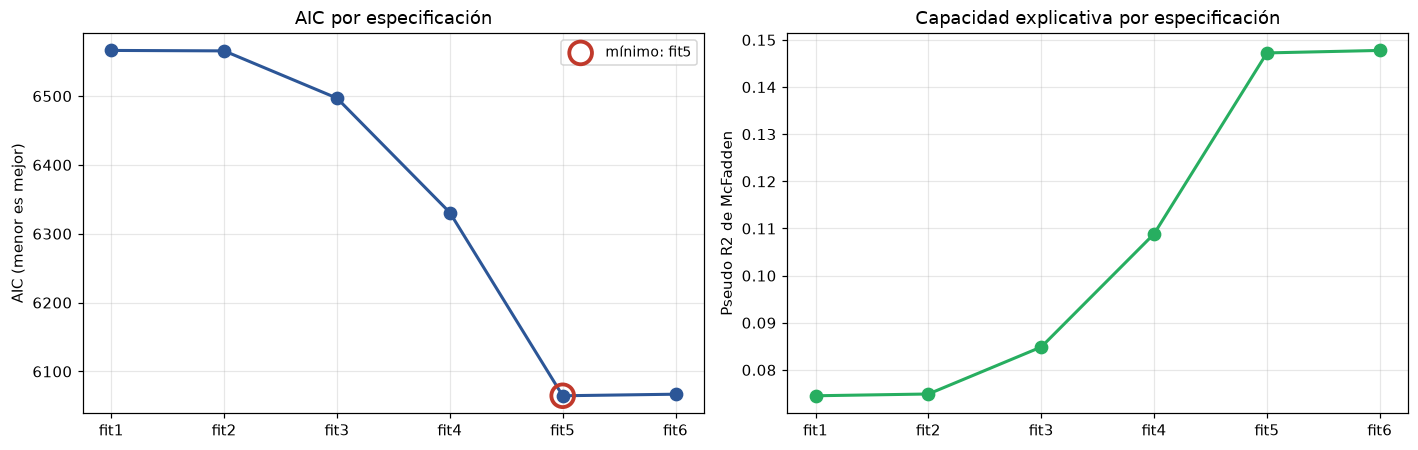

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(tabla_aic["Modelo"], tabla_aic["AIC"], "o-", lw=2, color=COL_PERM,
             markersize=8)
idx_min = tabla_aic["AIC"].idxmin()
axes[0].scatter([tabla_aic.loc[idx_min, "Modelo"]], [tabla_aic.loc[idx_min, "AIC"]],
                s=220, facecolor="none", edgecolor=COL_ABAN, lw=2.5,
                label=f"mínimo: {mejor}", zorder=5)
axes[0].set_ylabel("AIC (menor es mejor)")
axes[0].set_title("AIC por especificación")
axes[0].legend(fontsize=9)

axes[1].plot(tabla_aic["Modelo"], tabla_aic["Pseudo R2"], "o-", lw=2,
             color="#27AE60", markersize=8)
axes[1].set_ylabel("Pseudo R2 de McFadden")
axes[1].set_title("Capacidad explicativa por especificación")

plt.tight_layout()
plt.show()

In [29]:
# ¿Las tres variables que añade fit6 pagan su puesto?
# Prueba de razón de verosimilitud: fit6 (no restringido) vs fit5 (restringido)
lr = 2 * (fits["fit6"].llf - fits["fit5"].llf)
gl = int(fits["fit6"].df_model - fits["fit5"].df_model)
p_lr = 1 - scipy.stats.chi2.cdf(lr, gl)

print("PRUEBA DE RAZÓN DE VEROSIMILITUD  (fit6 frente a fit5)")
print("=" * 62)
print("H0: los coeficientes de antiguedad, tiene_tarjeta y salario_estimado son cero")
print()
print(f"log-verosimilitud fit5 : {fits['fit5'].llf:.4f}")
print(f"log-verosimilitud fit6 : {fits['fit6'].llf:.4f}")
print(f"Estadístico LR         : {lr:.4f}")
print(f"Grados de libertad     : {gl}")
print(f"Valor crítico (5%)     : {scipy.stats.chi2.ppf(0.95, gl):.4f}")
print(f"p-value                : {p_lr:.4f}")
print("-" * 62)
print(f"Decisión: {'RECHAZAR H0' if p_lr < 0.05 else 'NO RECHAZAR H0'}")
print()
print("p-values individuales de las tres candidatas en fit6:")
for v in ["antiguedad", "tiene_tarjeta", "salario_estimado"]:
    print(f"   {v:20s} p = {fits['fit6'].pvalues[v]:.4f}")

PRUEBA DE RAZÓN DE VEROSIMILITUD  (fit6 frente a fit5)
H0: los coeficientes de antiguedad, tiene_tarjeta y salario_estimado son cero

log-verosimilitud fit5 : -3023.3452
log-verosimilitud fit6 : -3021.4781
Estadístico LR         : 3.7342
Grados de libertad     : 3
Valor crítico (5%)     : 7.8147
p-value                : 0.2916
--------------------------------------------------------------
Decisión: NO RECHAZAR H0

p-values individuales de las tres candidatas en fit6:
   antiguedad           p = 0.2640
   tiene_tarjeta        p = 0.1879
   salario_estimado     p = 0.3973


## 5.3 Modelo de trabajo

Se adopta `fit5` como `logit_fits`: tiene el menor AIC y la prueba de razón de verosimilitud
indica que las tres variables adicionales de `fit6` no aportan.

In [30]:
logit_fits = fits["fit5"]
print(logit_fits.summary())

                           Logit Regression Results                           
Dep. Variable:               abandono   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6991
Method:                           MLE   Df Model:                            8
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                  0.1472
Time:                        15:08:53   Log-Likelihood:                -3023.3
converged:                       True   LL-Null:                       -3545.4
Covariance Type:            nonrobust   LLR p-value:                4.644e-220
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -3.6600      0.275    -13.286      0.000      -4.200      -3.120
C(sexo)[T.Hombre]      -0.5239      0.065     -8.078      0.000      -0.651      -0.397
C(pais)[T.Aleman

In [31]:
# Odds ratios con intervalo de confianza
OR = pd.DataFrame({
    "Coeficiente": logit_fits.params,
    "Error estándar": logit_fits.bse,
    "p-value": logit_fits.pvalues,
    "Odds ratio": np.exp(logit_fits.params),
    "IC 2.5%": np.exp(logit_fits.conf_int()[0]),
    "IC 97.5%": np.exp(logit_fits.conf_int()[1])})
OR["Lectura"] = np.where(
    OR["p-value"] >= 0.05, "No significativa",
    np.where(OR["Odds ratio"] > 1, "RIESGO (más abandono)", "PROTECTOR (menos abandono)"))
OR.loc["Intercept", "Lectura"] = "n/a"
display(OR.round(4))

,Coeficiente,Error estándar,p-value,Odds ratio,IC 2.5%,IC 97.5%,Lectura
Intercept,-3.6600,0.2755,0.0000,0.0257,0.0150,0.0442,n/a
C(sexo)[T.Hombre],-0.5239,0.0649,0.0000,0.5922,0.5215,0.6725,PROTECTOR (menos abandono)
C(pais)[T.Alemania],0.7453,0.0806,0.0000,2.1071,1.7992,2.4677,RIESGO (más abandono)
C(pais)[T.España],0.0696,0.0828,0.4011,1.0720,0.9114,1.2610,No significativa
edad,0.0728,0.0031,0.0000,1.0756,1.0691,1.0820,RIESGO (más abandono)
puntaje_crediticio,-0.0004,0.0003,0.1863,0.9996,0.9989,1.0002,No significativa
saldo,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,RIESGO (más abandono)
numero_productos,-0.0888,0.0559,0.1121,0.9150,0.8201,1.0210,No significativa
miembro_activo,-1.0214,0.0683,0.0000,0.3601,0.3150,0.4117,PROTECTOR (menos abandono)


In [32]:
# Los OR por unidad no son comparables entre variables con escalas distintas:
# se reexpresan en incrementos con sentido de negocio.
print("ODDS RATIOS EN UNIDADES INTERPRETABLES")
print("=" * 62)
b = logit_fits.params
reescala = pd.DataFrame([
    {"Variable": "edad", "Incremento": "+1 año", "OR": np.exp(b["edad"])},
    {"Variable": "edad", "Incremento": "+10 años", "OR": np.exp(10 * b["edad"])},
    {"Variable": "saldo", "Incremento": "+1 EUR", "OR": np.exp(b["saldo"])},
    {"Variable": "saldo", "Incremento": "+10.000 EUR", "OR": np.exp(10000 * b["saldo"])},
    {"Variable": "puntaje_crediticio", "Incremento": "+100 puntos",
     "OR": np.exp(100 * b["puntaje_crediticio"])},
    {"Variable": "miembro_activo", "Incremento": "inactivo -> activo",
     "OR": np.exp(b["miembro_activo"])},
    {"Variable": "sexo", "Incremento": "Mujer -> Hombre",
     "OR": np.exp(b["C(sexo)[T.Hombre]"])},
    {"Variable": "pais", "Incremento": "Francia -> Alemania",
     "OR": np.exp(b["C(pais)[T.Alemania]"])},
    {"Variable": "pais", "Incremento": "Francia -> España",
     "OR": np.exp(b["C(pais)[T.España]"])},
])
display(reescala.round(4))

ODDS RATIOS EN UNIDADES INTERPRETABLES


,Variable,Incremento,OR
0,edad,+1 año,1.0756
1,edad,+10 años,2.0718
2,saldo,+1 EUR,1.0000
3,saldo,+10.000 EUR,1.0293
4,puntaje_crediticio,+100 puntos,0.9569
5,miembro_activo,inactivo -> activo,0.3601
6,sexo,Mujer -> Hombre,0.5922
7,pais,Francia -> Alemania,2.1071
8,pais,Francia -> España,1.0720


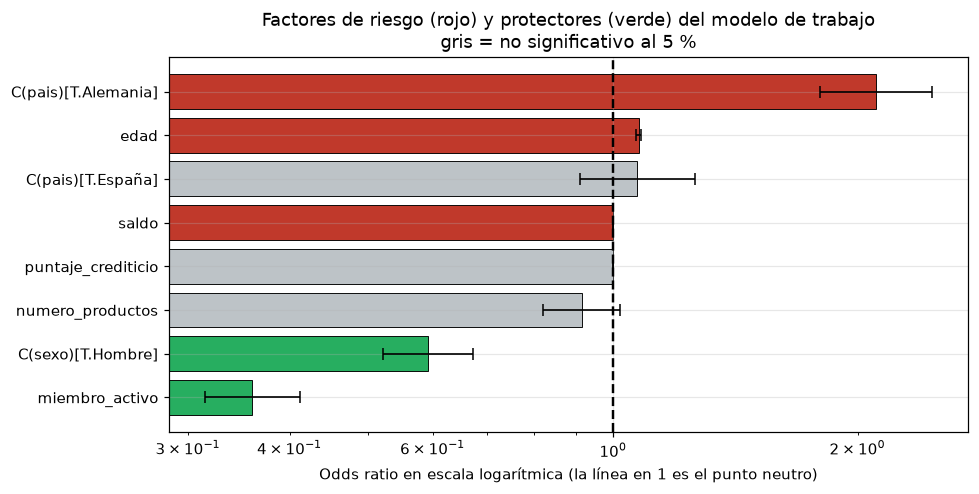

In [33]:
# Gráfico de odds ratios (escala logarítmica: 1 es el punto neutro)
plot_or = OR.drop(index="Intercept").sort_values("Odds ratio")
colores = [("#BDC3C7" if p >= 0.05 else (COL_ABAN if o > 1 else "#27AE60"))
           for o, p in zip(plot_or["Odds ratio"], plot_or["p-value"])]

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(plot_or.index, plot_or["Odds ratio"], color=colores,
        edgecolor="black", linewidth=0.6)
ax.errorbar(plot_or["Odds ratio"], range(len(plot_or)),
            xerr=[plot_or["Odds ratio"] - plot_or["IC 2.5%"],
                  plot_or["IC 97.5%"] - plot_or["Odds ratio"]],
            fmt="none", ecolor="black", capsize=4, lw=1.1)
ax.axvline(1, color="black", ls="--", lw=1.6)
ax.set_xscale("log")
ax.set_xlabel("Odds ratio en escala logarítmica (la línea en 1 es el punto neutro)")
ax.set_title("Factores de riesgo (rojo) y protectores (verde) del modelo de trabajo\n"
             "gris = no significativo al 5 %")
plt.tight_layout()
plt.show()

### Respuestas (sección 5)

**14. ¿Cuántas filas quedan en *train* y en *test*? ¿Se conserva la tasa de abandono?**

7.000 filas en entrenamiento y 3.000 en prueba, exactamente el 70/30 pedido.

| Conjunto | $n$ | Abandonos | Tasa |
|---|---:|---:|---:|
| Base completa | 10.000 | 2.037 | 20,37 % |
| Entrenamiento | 7.000 | 1.431 | 20,44 % |
| Prueba | 3.000 | 606 | 20,20 % |

**Sí se conserva.** La mayor desviación respecto a la tasa global es de 0,17 puntos
porcentuales. La partición es aleatoria simple, no estratificada, pero con $n = 10.000$ y una
tasa del 20 % el azar reparte la clase minoritaria de forma muy pareja. Esto importa porque, si la
proporción difiriera entre conjuntos, los indicadores de la sección 6 no serían comparables con lo
observado en entrenamiento.

**15. ¿Con qué especificación se queda y por qué? ¿`antiguedad`, `tiene_tarjeta` o `salario_estimado` pagan su puesto?**

**Se adopta `fit5`.** El AIC baja de forma sostenida al añadir información real y vuelve a subir
cuando se agregan variables que no aportan:

| Modelo | Añade | $k$ | AIC | $\Delta$AIC |
|---|---|---:|---:|---:|
| fit1 | `edad` | 1 | 6.566,30 | +501,61 |
| fit2 | `+ puntaje_crediticio` | 2 | 6.565,65 | +500,96 |
| fit3 | `+ C(sexo)` | 3 | 6.496,97 | +432,28 |
| fit4 | `+ C(pais)` | 5 | 6.330,81 | +266,12 |
| fit5 | `+ saldo, numero_productos, miembro_activo` | 8 | 6.064,69 | 0,00 |
| fit6 | `+ antiguedad, tiene_tarjeta, salario_estimado` | 11 | 6.066,96 | +2,27 |

El salto decisivo está en fit4 → fit5 (−266 puntos de AIC): `miembro_activo` y el bloque de
posición financiera son lo que realmente explica el abandono. También es notable que `fit2` apenas
mejore a `fit1` (−0,65), lo que confirma lo visto en la sección 3: `puntaje_crediticio` no
discrimina.

Las tres variables de `fit6` no pagan su puesto, y hay dos argumentos convergentes:

1. **AIC:** `fit6` es 2,27 puntos peor que `fit5`. Añadir tres parámetros empeora el criterio.
2. Prueba de razón de verosimilitud de $H_0: \beta_{\text{antiguedad}} =
   \beta_{\text{tarjeta}} = \beta_{\text{salario}} = 0$: LR = 3,7342 con 3 grados de libertad y
   $p = 0{,}2916$. No se rechaza $H_0$. Individualmente tampoco se acercan:
   `antiguedad` $p = 0{,}264$, `tiene_tarjeta` $p = 0{,}188$, `salario_estimado` $p = 0{,}397$.

El resultado de `tiene_tarjeta` era previsible desde la sección 3 ($\chi^2 = 0{,}47$;
$p = 0{,}492$), y el de `salario_estimado` es coherente con su distribución casi uniforme: una
variable que parece simulada difícilmente puede explicar una decisión real.

**16. Factores de riesgo y factores protectores del modelo de trabajo.**

Las dummies se leen contra Francia y Mujer.

Factores de RIESGO ($OR > 1$):

- `pais` = Alemania, OR = 2,107 ($p < 0{,}001$; IC 95 %: 1,799–2,468). Un cliente alemán tiene
  un *odds* de abandono 2,1 veces el de uno francés comparable en todo lo demás. Es el efecto
  categórico más fuerte del modelo y sobrevive al control por saldo, lo que descarta que sea solo
  el artefacto del saldo cero detectado en la sección 3.
- `edad`, OR = 1,0756 por año ($p < 0{,}001$). Reexpresado, cada década multiplica el *odds*
  por 2,07: el riesgo se duplica cada diez años de edad. Nótese que el efecto es mayor que en el
  logit simple de la sección 4 (1,88 por década), porque ahora se controla por el resto del perfil.
- `saldo`, OR = 1,000003 por euro ($p < 0{,}001$). Por unidad parece nulo, pero es un problema
  de escala: cada 10.000 EUR adicionales multiplican el *odds* por 1,029, y una desviación
  estándar completa (62.397 EUR) lo multiplica por 1,198. Es un efecto real pero modesto.

Factores PROTECTORES ($OR < 1$):

- `miembro_activo`, OR = 0,360 ($p < 0{,}001$; IC 95 %: 0,315–0,412). El efecto más fuerte
  del modelo. Ser cliente activo reduce el *odds* de abandono en un 64 %; visto al revés, un
  inactivo tiene 2,78 veces el *odds* de un activo. Y es la única variable del modelo sobre la que
  el banco puede actuar directamente.
- `sexo` = Hombre, OR = 0,592 ($p < 0{,}001$). Los hombres tienen un *odds* de abandono un
  41 % menor que las mujeres, manteniendo constante el resto.

**Variables NO significativas al 5 %:**

- `pais` = España, OR = 1,072 ($p = 0{,}401$). España no se distingue de Francia. El efecto
  país no es «tres niveles distintos» sino Alemania frente al resto.
- `puntaje_crediticio`, OR = 0,9996 por punto ($p = 0{,}186$), equivalente a 0,957 por cada
  100 puntos. Confirma el bivariado.
- `numero_productos`, OR = 0,915 ($p = 0{,}112$). Este resultado merece explicación, porque
  contradice aparentemente la sección 3, donde era la variable con mayor asociación (V de Cramér =
  0,388). Se examina en la celda siguiente.

In [34]:
# ¿Por qué numero_productos no es significativa si en el bivariado era la más fuerte?
# COMPLEMENTO: no forma parte de lo pedido; el diccionario indica tratarla como continua.
F_factor = formulas["fit5"].replace("numero_productos", "C(numero_productos)")
fit5_factor = smf.logit(F_factor, data=Train_Data).fit(disp=0)

print("numero_productos: LINEAL frente a FACTOR")
print("=" * 62)
print(f"AIC con la variable lineal : {logit_fits.aic:,.2f}")
print(f"AIC con la variable factor : {fit5_factor.aic:,.2f}")
print(f"Diferencia de AIC          : {logit_fits.aic - fit5_factor.aic:,.2f}")
print()
lr_f = 2 * (fit5_factor.llf - logit_fits.llf)
gl_f = int(fit5_factor.df_model - logit_fits.df_model)
print(f"LR = {lr_f:.2f}  gl = {gl_f}  "
      f"p = {1 - scipy.stats.chi2.cdf(lr_f, gl_f):.3e}")
print()
print("Odds ratios del factor (referencia = 1 producto):")
for nivel in ["C(numero_productos)[T.2]", "C(numero_productos)[T.3]",
              "C(numero_productos)[T.4]"]:
    print(f"   {nivel:28s} OR = {np.exp(fit5_factor.params[nivel]):>14,.2f}   "
          f"p = {fit5_factor.pvalues[nivel]:.4f}")

numero_productos: LINEAL frente a FACTOR
AIC con la variable lineal : 6,064.69
AIC con la variable factor : 5,239.97
Diferencia de AIC          : 824.72

LR = 828.72  gl = 2  p = 0.000e+00

Odds ratios del factor (referencia = 1 producto):
   C(numero_productos)[T.2]     OR =           0.21   p = 0.0000
   C(numero_productos)[T.3]     OR =          13.54   p = 0.0000
   C(numero_productos)[T.4]     OR = 481,404,169.73   p = 0.9922


**Por qué `numero_productos` sale no significativa.** Porque el logit le ajusta una sola
pendiente y la relación real tiene forma de U (27,7 % → 7,6 % → 82,7 % → 100 %). La pendiente
única promedia la caída del primer tramo con la subida del segundo y el resultado neto es casi
cero: de ahí el $p = 0{,}112$.

No es que la variable no importe (importa más que ninguna otra), sino que entra al modelo con la
forma funcional equivocada. Al dejarla como factor, el AIC cae 824 puntos (de 6.064,69 a
5.239,97) y la prueba de razón de verosimilitud da $p \approx 0$: con dos productos el *odds* es
0,21 veces el de un solo producto, y con tres, 13,5 veces.

> ⚠️ Dos advertencias. El nivel de 4 productos sufre separación cuasi completa (los 60
> clientes abandonaron sin excepción), por lo que su coeficiente no converge y no es interpretable.
> Y este ajuste no se adopta como modelo de trabajo: el diccionario del enunciado especifica
> tratar `numero_productos` como continua, y así se mantiene en `logit_fits`. Queda documentado
> como la limitación más importante de la especificación pedida.

---
> 📌 Cierre de sección: `git commit -m "Punto 5: modelos y odds ratios"` y `git push`.